# Assess peakVI in vitro multiome output

In [1]:
here::i_am("atac/archR/dimensionality_reduction/peakVI/peakVI_get_anndata.ipynb")

suppressPackageStartupMessages(library(uwot))
#suppressPackageStartupMessages(library(destiny))


# Load default settings
source(here::here("settings.R"))
source(here::here("utils.R"))

BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code



In [3]:
args <- list()
args$metadata <- file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")
args$outdir = file.path(io$basedir, 'results/atac/archR/dimensionality_reduction/peakVI/')
# I/O
dir.create(args$outdir, showWarnings=F, recursive=T)

In [4]:
##########################
## Load sample metadata ##
##########################

sample_metadata <- fread(args$metadata) %>%
  .[pass_rnaQC==TRUE & doublet_call==FALSE & pass_atacQC==TRUE] %>%
  .[,exp:=str_replace_all(sample, opts$sample2exp)]

In [10]:
set.seed(1234)
args$min_dist = 0.3
args$n_neighbors = 35
get_umap = function(n_neighbors = 25, min_dist=0.3, plot=FALSE){
    umap.mtx = umap(latent, 
                    n_neighbors = n_neighbors,
                    min_dist = min_dist,
                    n_threads  = 12)

    # Fetch UMAP coordinates
    umap.dt <- umap.mtx %>% as.data.table %>% 
      .[,cell:=sample_metadata$cell] %>%
      setnames(c("UMAP1","UMAP2","cell")) %>%
      merge(.,sample_metadata[,c('cell', 'celltype', 'day', 'exp', 'genotype')], by='cell')

    # Plot umap
    p1 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=celltype)) + 
        geom_point(size=1) + 
        scale_colour_manual(values=opts$celltype.colors) + 
        ggtitle('celltype') + 
        theme_void() + 
        theme(legend.position="none")
    p2 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=day)) + 
        geom_point(size=1) + 
        scale_colour_manual(values=opts$days.colors) + 
        ggtitle('day') + 
        theme_void() + 
        theme(legend.position="none")
    p3 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=exp)) + 
        geom_point(size=1) + 
        ggtitle('experiment') + 
        theme_void() + 
        theme(legend.position="none")
    p4 = ggplot(umap.dt, aes(UMAP1, UMAP2, col=genotype)) + 
        geom_point(size=1) + 
        scale_colour_manual(values=c('wt'='black', 'eomes_ko'='red')) + 
        ggtitle('genotype') + 
        theme_void() + 
        theme(legend.position="none")
    options(repr.plot.width=20, repr.plot.height=10)
    
    if(plot==TRUE){ggarrange(p1, p2, p3, p4)}
    else{return(umap.dt)}
    
}

# Model 1

In [8]:
latent = fread(sprintf('%s/peakVI_latent.csv', args$outdir))[-1,-1] 

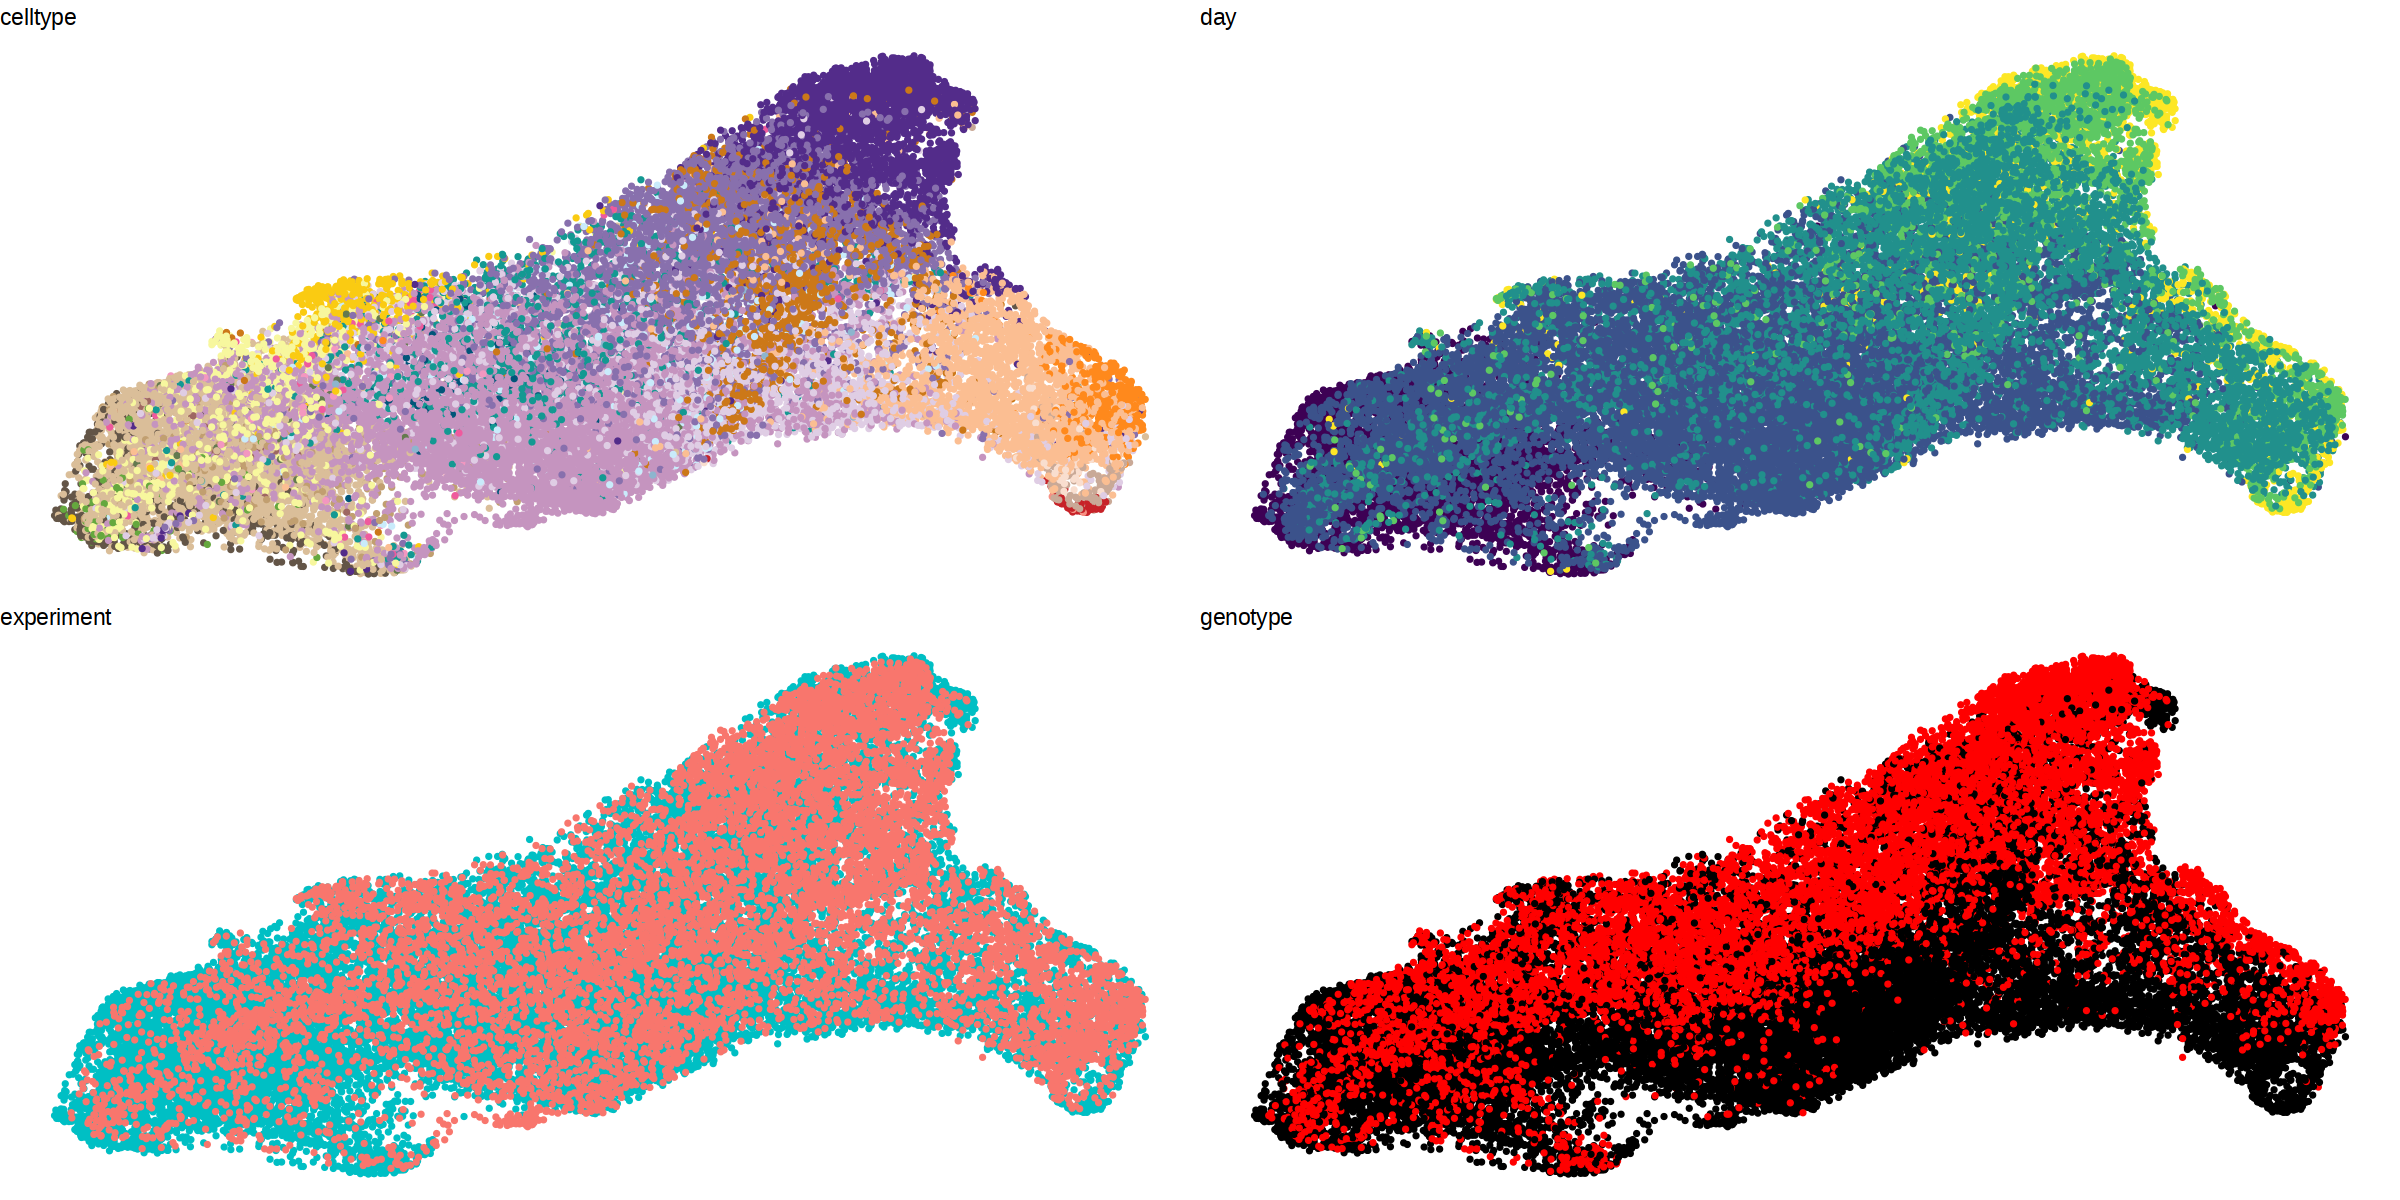

In [11]:
get_umap(25, 0.2, plot=TRUE)

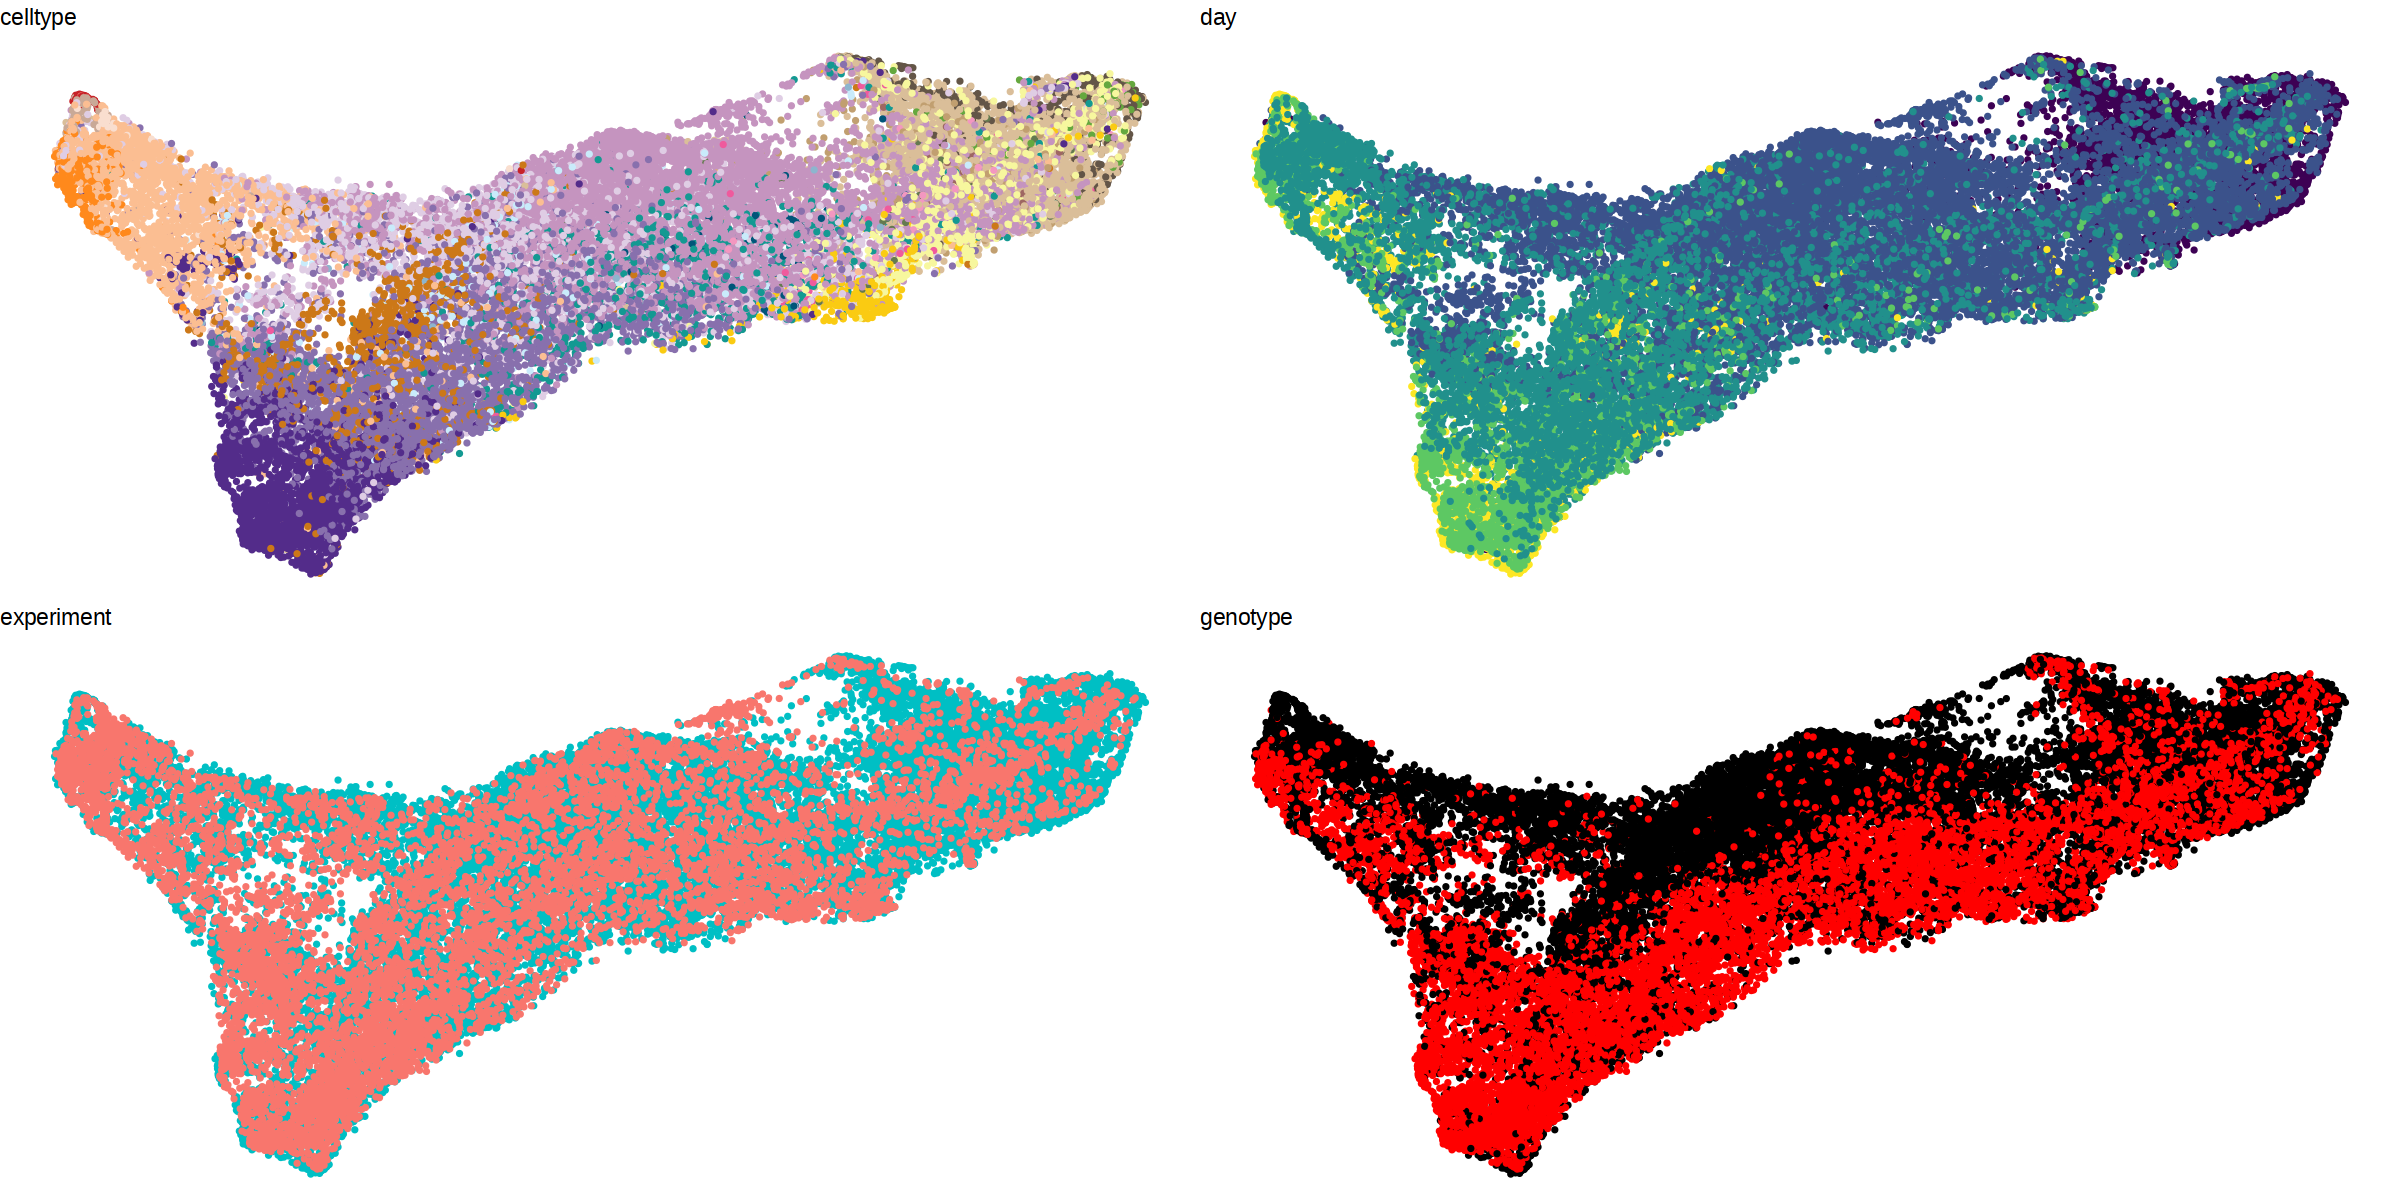

In [12]:
get_umap(25, 0.01, plot=TRUE)